# Forecast Error and Inventory Risk

The forecasting notebooks selected one model per category using validation results. This notebook studies when those forecasts miss and how errors accumulate across hypothetical lead times.

Validation errors calibrate the historical buffers. Final-test errors remain separate and are used for the policy evaluation in notebook 09.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


## Load Results

The selected models are unchanged. Validation forecasts come from the same 13 expanding windows used for model selection.


In [2]:
validation_summary = pd.read_parquet(
    "data/processed/all_model_validation_summary.parquet"
)
test_forecasts = pd.read_parquet(
    "data/processed/final_test_forecasts.parquet"
)

validation_files = [
    "rolling_28d_validation_forecasts.parquet",
    "linear_regression_validation_forecasts.parquet",
    "prophet_validation_forecasts.parquet",
    "xgboost_validation_forecasts.parquet",
]
validation_forecasts = pd.concat(
    [
        pd.read_parquet(f"data/processed/{name}")
        for name in validation_files
    ],
    ignore_index=True,
)

print("Validation forecasts:", validation_forecasts.shape)
print("Test forecasts:", test_forecasts.shape)


Validation forecasts: (15330, 6)
Test forecasts: (7665, 5)


In [3]:
validation_winners = (
    validation_summary
    .sort_values(["cat_id", "Mean_WAPE", "Std_WAPE"])
    .groupby("cat_id", observed=True)
    .first()
    .reset_index()
)

winner_columns = validation_winners[["cat_id", "Model"]]

validation_selected = (
    validation_forecasts
    .merge(winner_columns, on=["cat_id", "Model"], how="inner")
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)
test_selected = (
    test_forecasts
    .merge(winner_columns, on=["cat_id", "Model"], how="inner")
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)

assert validation_selected.duplicated(["cat_id", "ds"]).sum() == 0
assert test_selected.duplicated(["cat_id", "ds"]).sum() == 0
assert (validation_selected.groupby("cat_id").size() == 365).all()
assert (test_selected.groupby("cat_id").size() == 365).all()

validation_winners[["cat_id", "Model", "Mean_WAPE", "Std_WAPE"]]


,cat_id,Model,Mean_WAPE,Std_WAPE
0,FOODS,XGBoost Faster,6.99,1.91
1,HOBBIES,Linear Regression (Full),6.50,1.48
2,HOUSEHOLD,Prophet Flexible,6.88,1.99


## Forecast Errors

Residuals are calculated as `actual - forecast`. Positive values are under-forecasts; negative values are over-forecasts.


In [4]:
def add_errors(data, period):
    result = data.copy()
    result["period"] = period
    result["residual"] = result["actual"] - result["forecast"]
    result["absolute_error"] = result["residual"].abs()
    result["under_forecast_units"] = result["residual"].clip(lower=0)
    result["over_forecast_units"] = (-result["residual"]).clip(lower=0)
    return result


validation_risk = add_errors(validation_selected, "validation")
test_risk = add_errors(test_selected, "test")

error_summary = (
    test_risk
    .groupby("cat_id", observed=True)
    .agg(
        mean_residual=("residual", "mean"),
        median_residual=("residual", "median"),
        mae=("absolute_error", "mean"),
        under_forecast_rate=("residual", lambda x: (x > 0).mean()),
        over_forecast_rate=("residual", lambda x: (x < 0).mean()),
        under_forecast_units=("under_forecast_units", "sum"),
        over_forecast_units=("over_forecast_units", "sum"),
    )
    .round(2)
)

error_summary


,mean_residual,median_residual,mae,under_forecast_rate,over_forecast_rate,under_forecast_units,over_forecast_units
cat_id,,,,,,,
FOODS,1095.27,1043.87,2722.43,0.64,0.36,696729.17,296956.35
HOBBIES,244.44,235.00,346.31,0.76,0.24,107811.09,18591.57
HOUSEHOLD,-387.26,-460.86,812.54,0.31,0.69,77615.36,218963.45


The final-test residuals describe forecast exposure, not observed Walmart stockouts or inventory positions.


## When Errors Occur


In [5]:
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday",
]

test_risk["day_of_week"] = test_risk["ds"].dt.day_name()
test_risk["month"] = test_risk["ds"].dt.month

under_rate_by_day = (
    test_risk
    .assign(is_under=test_risk["residual"] > 0)
    .groupby(["cat_id", "day_of_week"], observed=True)["is_under"]
    .mean()
    .unstack()
    .reindex(columns=day_order)
)

under_rate_by_day.round(3)


day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
cat_id,,,,,,,
FOODS,0.404,0.462,0.538,0.635,0.635,0.942,0.830
HOBBIES,0.712,0.731,0.750,0.712,0.692,0.885,0.811
HOUSEHOLD,0.192,0.135,0.173,0.173,0.231,0.577,0.679


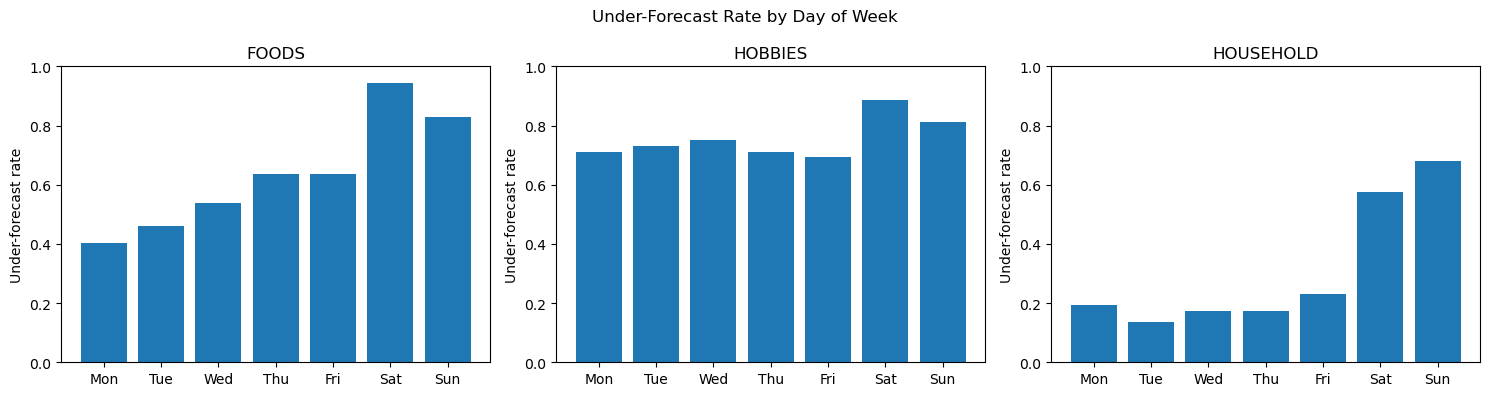

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, category in zip(axes, ["FOODS", "HOBBIES", "HOUSEHOLD"]):
    values = under_rate_by_day.loc[category]
    ax.bar([day[:3] for day in day_order], values)
    ax.set_title(category)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Under-forecast rate")

fig.suptitle("Under-Forecast Rate by Day of Week")
plt.tight_layout()
plt.show()


## Lead-Time Error

Validation residuals are accumulated over hypothetical 7-, 14-, 21-, and 28-day horizons. Because every validation-day forecast was generated out of sample, these errors can calibrate buffers without using final-test results.


In [7]:
lead_times = [7, 14, 21, 28]
lead_time_frames = []

for lead_time in lead_times:
    frame = validation_risk[
        ["cat_id", "ds", "actual", "forecast", "residual"]
    ].copy()
    frame["lead_time_days"] = lead_time
    frame["lead_time_error"] = (
        frame
        .groupby("cat_id", observed=True)["residual"]
        .transform(lambda x: x.rolling(lead_time).sum())
    )
    lead_time_frames.append(frame.dropna())

lead_time_errors = pd.concat(lead_time_frames, ignore_index=True)

lead_time_summary = (
    lead_time_errors
    .groupby(["cat_id", "lead_time_days"], observed=True)
    .agg(
        mean_error=("lead_time_error", "mean"),
        share_positive=("lead_time_error", lambda x: (x > 0).mean()),
        positive_windows=("lead_time_error", lambda x: (x > 0).sum()),
    )
    .reset_index()
    .round(2)
)

lead_time_summary


,cat_id,lead_time_days,mean_error,share_positive,positive_windows
0,FOODS,7,3975.61,0.62,222
1,FOODS,14,7805.91,0.68,240
2,FOODS,21,11164.24,0.72,249
3,FOODS,28,14430.49,0.74,249
4,HOBBIES,7,297.02,0.60,214
5,HOBBIES,14,655.86,0.66,234
6,HOBBIES,21,1033.14,0.70,241
7,HOBBIES,28,1405.85,0.77,260
8,HOUSEHOLD,7,1881.85,0.76,272
9,HOUSEHOLD,14,3869.22,0.83,293


## Historical Buffers

The buffers are percentiles of positive cumulative validation errors. They are sample-based protection levels, not guaranteed service levels or Walmart operating parameters.


In [8]:
positive_errors = lead_time_errors[
    lead_time_errors["lead_time_error"] > 0
]

empirical_buffers = (
    positive_errors
    .groupby(["cat_id", "lead_time_days"], observed=True)["lead_time_error"]
    .quantile([0.90, 0.95, 0.98])
    .unstack()
    .rename(columns={0.90: "buffer_90", 0.95: "buffer_95", 0.98: "buffer_98"})
    .reset_index()
)

positive_counts = (
    positive_errors
    .groupby(["cat_id", "lead_time_days"], observed=True)
    .size()
    .rename("positive_windows")
    .reset_index()
)
empirical_buffers = empirical_buffers.merge(
    positive_counts,
    on=["cat_id", "lead_time_days"],
    how="left",
)

empirical_buffers.round(1)


,cat_id,lead_time_days,buffer_90,buffer_95,buffer_98,positive_windows
0,FOODS,7,21568.7,24436.8,28780.3,222
1,FOODS,14,33495.5,43549.8,49009.0,240
2,FOODS,21,44674.9,48933.5,54743.1,249
3,FOODS,28,51818.9,57081.2,59366.0,249
4,HOBBIES,7,1829.4,2076.9,2169.7,214
5,HOBBIES,14,2798.0,3278.1,3737.5,234
6,HOBBIES,21,3820.5,4477.9,5054.9,241
7,HOBBIES,28,4506.3,5590.1,6220.7,260
8,HOUSEHOLD,7,5864.9,6433.4,7425.6,272
9,HOUSEHOLD,14,8377.6,10086.9,12881.1,293


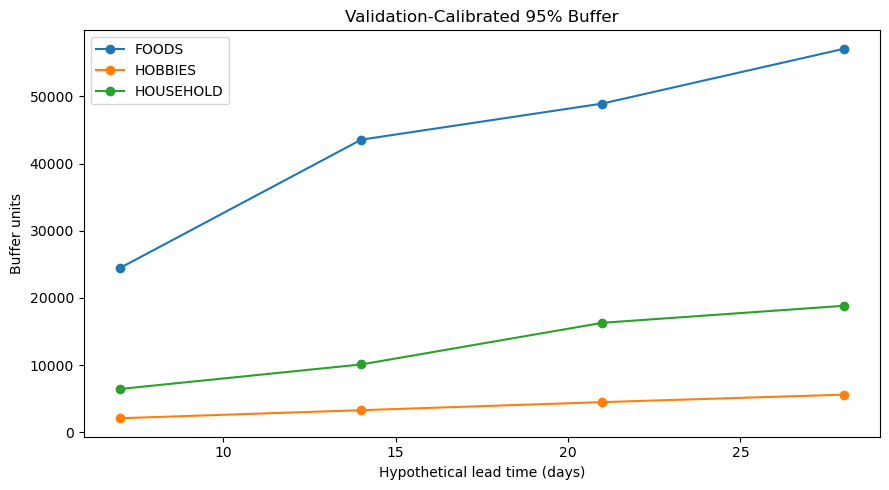

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

for category in ["FOODS", "HOBBIES", "HOUSEHOLD"]:
    plot_data = empirical_buffers[
        empirical_buffers["cat_id"] == category
    ]
    ax.plot(
        plot_data["lead_time_days"],
        plot_data["buffer_95"],
        marker="o",
        label=category,
    )

ax.set_title("Validation-Calibrated 95% Buffer")
ax.set_xlabel("Hypothetical lead time (days)")
ax.set_ylabel("Buffer units")
ax.legend()
plt.tight_layout()
plt.show()


## Findings

- Final-test errors remain category-specific: `FOODS` and `HOBBIES` tend to under-forecast, while `HOUSEHOLD` tends to over-forecast.
- Under-forecast exposure is concentrated on weekends.
- Longer lead times accumulate more forecast error and require larger historical buffers.
- Buffers are calibrated only from validation residuals. Notebook 09 evaluates them on the separate final-test period.


In [10]:
validation_risk.to_parquet(
    "data/processed/validation_inventory_risk_daily.parquet",
    index=False,
)
test_risk.to_parquet(
    "data/processed/inventory_risk_daily.parquet",
    index=False,
)
lead_time_summary.to_parquet(
    "data/processed/lead_time_error_summary.parquet",
    index=False,
)
empirical_buffers.to_parquet(
    "data/processed/empirical_inventory_buffers.parquet",
    index=False,
)

print("Saved validation residuals, test residuals, lead-time summary, and buffers.")


Saved validation residuals, test residuals, lead-time summary, and buffers.
